### Steps
Get excel doc
Iterate over each cell and get the link from the first column
Identify the pdf file and its location
Identify image which is most useful (size, quality, etc.)
append image to excel doc as a comment (column E)


In [124]:
input_excel = 'LVM Applications Database - v6 - DB tab only.xlsx'
output_excel = 'EditedOutput.xlsx'
img_folder = 'data/applicationsDB/new/'

In [125]:
# IMPORTS
import os
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.comments import Comment
from PIL import Image
from matplotlib import pyplot as plt

In [ ]:
import os
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.comments import Comment

# ---- CONFIGURATION ----
min_file_size = 1e6  # 1 MB
image_width = 150
image_height = 150

# ---- LOAD EXCEL WORKBOOK ----
wb = load_workbook(input_excel)
ws = wb.active

# ---- MAIN LOOP ----
for row in ws.iter_rows(min_row=2, min_col=2, max_col=2):
    cell = row[0]  # This is column B

    # Parse PDF hyperlink target
    try:
        pdf_path = cell.hyperlink.target.replace('%20', ' ')
        file_name = os.path.basename(pdf_path)
        subfolder_name = os.path.basename(os.path.dirname(pdf_path))
        subfolder_path = os.path.join(os.getcwd()[:-20], img_folder, subfolder_name)
        if not os.path.exists(subfolder_path):
            print(f"Missing subfolder: {subfolder_path}")
            continue
    except AttributeError:
        print(f"No hyperlink in cell {cell.coordinate}")
        continue

    # Find PNG images matching the base name
    candidate_files = [
        f for f in os.listdir(subfolder_path)
        if f.endswith('.png') and f.startswith(file_name.split('.')[0])
        and os.path.getsize(os.path.join(subfolder_path, f)) > min_file_size
    ]

    if not candidate_files:
        continue

    # Pick the largest file
    selected_image_path = max(
        (os.path.join(subfolder_path, f) for f in candidate_files),
        key=os.path.getsize
    )

    # Load image, resize, and insert
    xl_img = XLImage(selected_image_path)3
    xl_img.width = image_width
    xl_img.height = image_height
    anchor_cell = f"E{cell.row}"
    xl_img.anchor = anchor_cell
    ws.add_image(xl_img)
    ws.row_dimensions[cell.row].height = 120

    # Add a text comment as a "caption"
    ws[anchor_cell].comment = Comment("Image preview", "AutoGen")

# ---- SAVE RESULT ----
wb.save(output_excel)
print(f"Saved with images to: {output_excel}")

No hyperlink in cell B134
No hyperlink in cell B135
No hyperlink in cell B666
Saved with images to: EditedOutput.xlsx


In [112]:
wb = load_workbook('LVM Applications Database - v6 - DB tab only.xlsx') 
ws = wb.active  # Get the active worksheet

sizes = []

for row in ws.iter_rows(min_row=2, min_col=2, max_col=2):
    cell = row[0]
    
    # Get the hyperlink from the cell
    try:
        pdf_path = cell.hyperlink.target.replace('%20', ' ')
        file_name, subfolder_name = pdf_path.split('/')[-1], pdf_path.split('/')[-2]
        subfolder_path = os.path.join(os.getcwd()[:-20], img_folder, subfolder_name + '/')
        if not os.path.exists(subfolder_path):
            raise FileNotFoundError(f"Subfolder {os.getcwd()[:-20] + subfolder_path} does not exist.")
    except AttributeError:
        print(f"Hyperlink problem in cell {cell.coordinate}")
        pass

    # get .png
    files = sorted([f for f in os.listdir(subfolder_path) if f.endswith('.png') and f.startswith(file_name.split('.')[0])
                    and os.path.getsize(os.path.join(subfolder_path, f)) > 1e06],)
    if files:
        biggest_file = max(os.path.join(subfolder_path ,f) for f in files)
        xl_img = XLImage(biggest_file)
        # Insert image as comment
        comment_text = "Image preview below."
        comment = Comment(comment_text, "AutoGen")
        cell_offset = f"E{cell.row}"
        ws[cell_offset].comment = comment
        ws[cell_offset].comment.width = 300
        ws[cell_offset].comment.height = 300
        ws[cell_offset].comment._parent._parent._images.append(xl_img)
        xl_img.anchor = ws[cell_offset].coordinate

wb.save('ApplicationsOutput.xlsx')

AttributeError: 'Cell' object has no attribute '_parent'

NameError: name 'sizes' is not defined

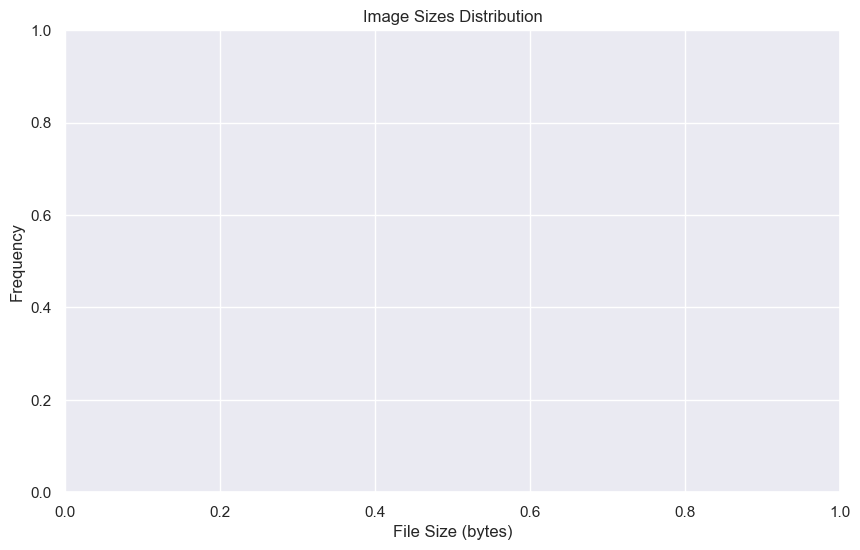

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Image Sizes Distribution')
ax.set_xlabel('File Size (bytes)')
ax.set_ylabel('Frequency')
ax.hist(sizes, bins=200, edgecolor='black')
ax.set_xlim(0, max(sizes) + 1000)  # Adjust x-axis limit for better visibility

plt.show()

In [ ]:


#     if not pdf_path or not pdf_path.lower().endswith('.pdf'):
#         continue

#     # Replace .pdf with .png and point to img_folder
#     rel_image_path = pdf_path.replace('.pdf', '.png')
#     image_path = os.path.join(img_folder, rel_image_path)

#     if not os.path.exists(image_path):
#         continue  # Image doesn't exist; skip

#     try:
#         # Load and optionally resize image
#         img = Image.open(image_path)
#         img.thumbnail((300, 300))  # Resize to fit in comment
#         thumb_path = '/tmp/thumb.png'
#         img.save(thumb_path)

#         # Add image as openpyxl Image
#         xl_img = XLImage(thumb_path)

#         # Insert image as comment
#         comment_text = "Image preview below."
#         comment = Comment(comment_text, "AutoGen")
#         cell_offset = f"E{cell.row}"
#         ws[cell_offset].comment = comment
#         ws[cell_offset].comment.width = 300
#         ws[cell_offset].comment.height = 300
#         ws[cell_offset].comment._parent._parent._images.append(xl_img)
#         xl_img.anchor = ws[cell_offset].coordinate
#     except Exception as e:
#         print(f"Failed to process {image_path}: {e}")

# # Save workbook
# wb.save('ApplicationsOutput.xlsx')


In [ ]:

# import pandas as pd
# from openpyxl import load_workbook
# from openpyxl.drawing.image import Image
# import os
# def add_images_to_excel(excel_file, image_folder):
#     # Load the Excel file
#     wb = load_workbook(excel_file)
#     ws = wb.active

#     # Iterate over each row in the first column
#     for row in range(2, ws.max_row + 1):  # Assuming the first row is a header
#         pdf_link = ws.cell(row=row, column=1).value
#         if pdf_link:
#             # Extract the PDF filename from the link
#             pdf_filename = os.path.basename(pdf_link)
#             image_filename = pdf_filename.replace('.pdf', '.png')  # Assuming images are PNGs
            
#             # Construct the full path to the image
#             image_path = os.path.join(image_folder, image_filename)
            
#             if os.path.exists(image_path):
#                 img = Image(image_path)
#                 img.anchor = f'E{row}'  # Place image in column E
#                 ws.add_image(img)

#     # Save the modified Excel file
#     wb.save(excel_file)
#     print(f"Images added to {excel_file} successfully.")